In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import kagglehub
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import joblib
from pathlib import Path
import time


/Users/amir/miniconda3/envs/maktab/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def save_model(model, model_name):
    joblib.dump(model, f'../_models/{model_name}_{time.strftime("%Y_%m_%d_%H_%M_%S")}.pkl')

def load_model(model_name):
    return joblib.load(f'../_models/{model_name}')


In [3]:
path = f'{kagglehub.dataset_download("mlg-ulb/creditcardfraud")}/creditcard.csv'

df = pd.read_csv(path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
target_column = 'Class'

In [5]:
X = df.drop(target_column, axis=1)
y = df[target_column]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(X_train.shape, X_test.shape)
print("Fraud rate train:", float(y_train.mean()), "test:", float(y_test.mean()))

(227845, 30) (56962, 30)
Fraud rate train: 0.001729245759178389 test: 0.0017204452090867595


In [8]:
dt_model_name = 'dt_random_search_result_2026_08_13_02_00_27.pkl'
knn_model_name = 'knn_random_search_result_2026_08_20_15_03_11.pkl'
rf_model_name = 'rf_random_search_result_2026_08_20_16_52_18.pkl'

dt_model = load_model(dt_model_name)
knn_model = load_model(knn_model_name)
rf_model = load_model(rf_model_name)


## Stacking

Do **not** train the meta-model on the base models' predictions for the same rows they were trained on. Those scores are too optimistic and leak the label.

Protocol used here:

1. Keep the original 80/20 stratified split (`random_state=42`). Never fit on `X_test`.
2. **Stacking train set:** out-of-fold `predict_proba` from each base model. Each row is scored by a clone that did not see that row.
3. **Stacking test set:** `predict_proba` from the saved models, which were already refit on full `X_train`.
4. Train a Random Forest only on the stacking train features. Evaluate on the stacking test features.

**Scaling:** the saved models are pipelines with `StandardScaler` inside, so pass **unscaled** `X_train` / `X_test`. Meta features are fraud probabilities in `[0, 1]`, already on one scale. Random Forest does not need scaling, so the meta-model has no scaler.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_feature_names = ["pred_dt", "pred_knn", "pred_rf"]

base_estimators = {
    "pred_dt": dt_model.best_estimator_,
    "pred_knn": knn_model.best_estimator_,
    "pred_rf": rf_model.best_estimator_,
}

oof_preds = {}
for name, estimator in base_estimators.items():
    print(f"Out-of-fold predict_proba: {name} (KNN can take a long time)")
    oof_preds[name] = cross_val_predict(
        clone(estimator),
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

stacking_train_data = pd.DataFrame(oof_preds)[meta_feature_names]
stacking_train_data["Class"] = np.asarray(y_train).ravel()
stacking_train_data.head()

Out-of-fold predict_proba: pred_dt (KNN can take a long time)
Out-of-fold predict_proba: pred_knn (KNN can take a long time)
Out-of-fold predict_proba: pred_rf (KNN can take a long time)


,pred_dt,pred_knn,pred_rf,Class
0,0.000009,0.0,0.0,0
1,0.000179,0.0,0.0,0
2,0.000048,0.0,0.0,0
3,0.000025,0.0,0.0,0
4,0.000179,0.0,0.0,0


In [10]:
stacking_test_data = pd.DataFrame({
    "pred_dt": dt_model.predict_proba(X_test)[:, 1],
    "pred_knn": knn_model.predict_proba(X_test)[:, 1],
    "pred_rf": rf_model.predict_proba(X_test)[:, 1],
})
stacking_test_data["Class"] = np.asarray(y_test).ravel()
stacking_test_data.head()


,pred_dt,pred_knn,pred_rf,Class
0,0.000014,0.0,0.0,0
1,0.000014,0.0,0.0,0
2,0.000000,0.0,0.0,0
3,0.000014,0.0,0.0,0
4,0.001303,0.0,0.0,0


In [11]:
Path("../_data").mkdir(parents=True, exist_ok=True)
stacking_train_data.to_csv("../_data/stacking_train_data.csv", index=False)
stacking_test_data.to_csv("../_data/stacking_test_data.csv", index=False)

print(stacking_train_data.shape, stacking_test_data.shape)
stacking_train_data.describe()

(227845, 4) (56962, 4)


,pred_dt,pred_knn,pred_rf,Class
count,227845.000000,227845.000000,227845.000000,227845.000000
mean,0.001722,0.001570,0.002429,0.001729
std,0.035391,0.037083,0.037375,0.041548
min,0.000000,0.000000,0.000000,0.000000
25%,0.000024,0.000000,0.000000,0.000000
50%,0.000025,0.000000,0.000000,0.000000
75%,0.000179,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


In [12]:
X_stack_train = stacking_train_data[meta_feature_names]
y_stack_train = stacking_train_data["Class"]
X_stack_test = stacking_test_data[meta_feature_names]
y_stack_test = stacking_test_data["Class"]

print("Train stacking fraud rate:", float(y_stack_train.mean()))
print("Test stacking fraud rate:", float(y_stack_test.mean()))
X_stack_train.corr()

Train stacking fraud rate: 0.001729245759178389
Test stacking fraud rate: 0.0017204452090867595


,pred_dt,pred_knn,pred_rf
pred_dt,1.000000,0.903787,0.921058
pred_knn,0.903787,1.000000,0.917205
pred_rf,0.921058,0.917205,1.000000


In [13]:
# Meta-features are already probabilities in [0, 1]; RF does not need a scaler.
rf_stacking_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions={
        "n_estimators": [50, 100, 200, 300, 500],
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 3, 5, 8, 10, 15, 20],
        "min_samples_split": list(range(2, 51)),
        "min_samples_leaf": list(range(1, 51)),
        "max_features": [1, 2, 3, "sqrt"],
        "class_weight": [None, "balanced", "balanced_subsample"],
        "bootstrap": [True, False],
    },
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=3,
)

rf_stacking_search.fit(X_stack_train, y_stack_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 4/5] END bootstrap=False, class_weight=None, criterion=gini, max_depth=8, max_features=2, min_samples_leaf=8, min_samples_split=31, n_estimators=50;, score=0.857 total time=   1.8s
[CV 3/5] END bootstrap=False, class_weight=None, criterion=gini, max_depth=8, max_features=2, min_samples_leaf=8, min_samples_split=31, n_estimators=50;, score=0.814 total time=   1.8s
[CV 2/5] END bootstrap=False, class_weight=None, criterion=gini, max_depth=8, max_features=2, min_samples_leaf=8, min_samples_split=31, n_estimators=50;, score=0.853 total time=   1.9s
[CV 5/5] END bootstrap=False, class_weight=None, criterion=gini, max_depth=8, max_features=2, min_samples_leaf=8, min_samples_split=31, n_estimators=50;, score=0.878 total time=   2.0s
[CV 1/5] END bootstrap=False, class_weight=None, criterion=gini, max_depth=8, max_features=2, min_samples_leaf=8, min_samples_split=31, n_estimators=50;, score=0.851 total time=   2.2s
[CV 1/5] END 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'class_weight': [None, 'balanced', ...], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can

In [14]:
print("Best stacking RF params:", rf_stacking_search.best_params_)
print("Best stacking RF CV F1:", rf_stacking_search.best_score_)

y_stack_train_pred = rf_stacking_search.predict(X_stack_train)
y_stack_test_pred = rf_stacking_search.predict(X_stack_test)

Best stacking RF params: {'n_estimators': 300, 'min_samples_split': 25, 'min_samples_leaf': 46, 'max_features': 1, 'max_depth': 20, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': True}
Best stacking RF CV F1: 0.8514368702828264


In [15]:
Path("../_models").mkdir(parents=True, exist_ok=True)
save_model(rf_stacking_search, "rf_stacking_search_result")


In [16]:
print("Base models on held-out X_test (unscaled; pipelines scale internally)")
for name, model in [("dt", dt_model), ("knn", knn_model), ("rf", rf_model)]:
    pred = model.predict(X_test)
    print(
        f"{name:4s}  f1={f1_score(y_test, pred):.4f}  "
        f"recall={recall_score(y_test, pred):.4f}  "
        f"precision={precision_score(y_test, pred):.4f}"
    )

print(
    f"stack f1={f1_score(y_stack_test, y_stack_test_pred):.4f}  "
    f"recall={recall_score(y_stack_test, y_stack_test_pred):.4f}  "
    f"precision={precision_score(y_stack_test, y_stack_test_pred):.4f}"
)

Base models on held-out X_test (unscaled; pipelines scale internally)
dt    f1=0.8306  recall=0.7755  precision=0.8941
knn   f1=0.8663  recall=0.8265  precision=0.9101
rf    f1=0.8148  recall=0.7857  precision=0.8462
stack f1=0.8663  recall=0.8265  precision=0.9101


In [17]:
def generate_evaluation_metrics(model_name, y_train, y_test, y_train_pred, y_test_pred):
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    precision_train = precision_score(y_train, y_train_pred)
    precision_test = precision_score(y_test, y_test_pred)
    recall_train = recall_score(y_train, y_train_pred)
    recall_test = recall_score(y_test, y_test_pred)

    class_labels = ["Legitimate", "Fraud"]
    report_dict = classification_report(
        y_test, y_test_pred, target_names=class_labels, output_dict=True
    )
    # accuracy is a scalar in the report dict, not a per-class metric like the others
    accuracy = report_dict.pop("accuracy")
    report_df = pd.DataFrame(report_dict).T
    report_df["accuracy"] = accuracy
    report_metrics = report_df[["precision", "recall", "f1-score", "support", "accuracy"]]

    cm = confusion_matrix(y_test, y_test_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        report_metrics,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=axes[0],
    )
    axes[0].set_title(f"{model_name} Classification Report")
    axes[0].set_ylabel("")

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axes[1],
    )
    axes[1].set_title(f"{model_name} Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "f1_train": f1_train,
        "f1_test": f1_test,
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test,
        "precision_train": precision_train,
        "precision_test": precision_test,
        "recall_train": recall_train,
        "recall_test": recall_test,
    }


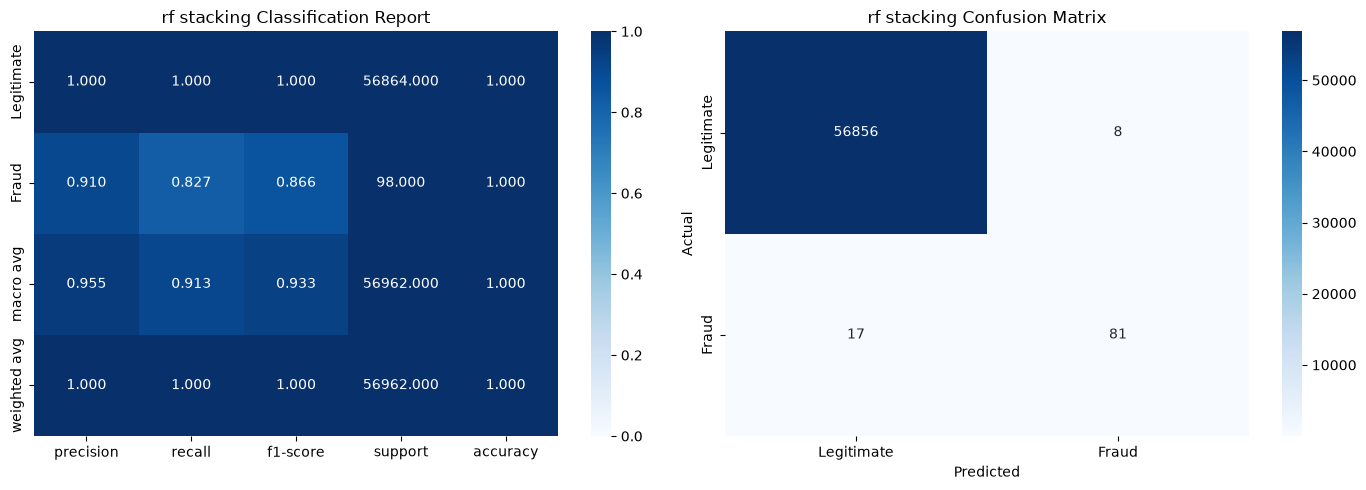

{'model_name': 'rf stacking',
 'f1_train': 0.850480109739369,
 'f1_test': 0.8663101604278075,
 'accuracy_train': 0.9995216045996181,
 'accuracy_test': 0.9995611109160493,
 'precision_train': 0.9253731343283582,
 'precision_test': 0.9101123595505618,
 'recall_train': 0.7868020304568528,
 'recall_test': 0.826530612244898}

In [18]:
generate_evaluation_metrics(
    "rf stacking",
    y_stack_train,
    y_stack_test,
    y_stack_train_pred,
    y_stack_test_pred,
)

In [19]:
pd.Series(
    rf_stacking_search.best_estimator_.feature_importances_,
    index=meta_feature_names,
).sort_values(ascending=False)

pred_dt     0.335820
pred_rf     0.333269
pred_knn    0.330912
dtype: float64

In [20]:
# Saved files:
# ../_data/stacking_train_data.csv  — OOF fraud probabilities + Class
# ../_data/stacking_test_data.csv   — holdout fraud probabilities + Class
# The meta-model trains only on the stacking train table. Test Class is for evaluation only.